# Energy Consumption Prediction - Part 3
## Building Diagnostics & Business Insights

**What we'll do in this notebook:**
1. Load validation data with predictions
2. Calculate building efficiency scores (0-100)
3. Detect waste patterns
4. Estimate savings potential
5. Generate building reports
6. Create portfolio visualizations
7. Identify priority buildings for retrofits

**Turning predictions into business value**

---
## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported!")

Libraries imported!


---
## Step 2: Load Data with Predictions

In [2]:
print("Loading validation data with predictions...")

df = pd.read_csv('validation_with_predictions.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Data loaded: {len(df):,} rows")
print(f"\nColumns available:")
print(df.columns.tolist())

print("\nSample data:")
display(df.head())

Loading validation data with predictions...
Data loaded: 79,561 rows

Columns available:
['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id', 'primary_use', 'square_feet', 'year_built', 'floor_count', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'hour', 'day', 'weekday', 'month', 'year', 'day_of_year', 'is_weekend', 'is_business_hours', 'is_night', 'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos', 'temp_squared', 'temp_diff', 'relative_humidity', 'heating_degree_days', 'cooling_degree_days', 'feels_like_temp', 'building_age', 'log_square_feet', 'area_per_floor', 'size_temp_interaction', 'weekend_hour', 'age_temp_interaction', 'primary_use_encoded', 'building_avg', 'building_meter_avg', 'building_log_avg', 'predicted', 'error', 'abs_error', 'pct_error']

Sample data:


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,...,weekend_hour,age_temp_interaction,primary_use_encoded,building_avg,building_meter_avg,building_log_avg,predicted,error,abs_error,pct_error
0,1002,0,2016-12-01,83.0002,10,1,161969,1970.0,1.0,-0.6,...,0,0.0,1,162.413845,162.413845,5.096286,32.340463,50.659737,50.659737,60.309067
1,308,0,2016-12-01,8.7900,3,9,5033,1970.0,0.0,16.7,...,0,0.0,9,9.623143,9.623143,2.363035,167.305625,-158.515625,158.515625,1619.158582
2,497,0,2016-12-01,9.4900,3,9,7732,1970.0,0.0,16.7,...,0,0.0,9,10.229130,10.229130,2.418511,230.550045,-221.060045,221.060045,2107.340757
3,997,0,2016-12-01,43.0000,9,6,38173,1970.0,0.0,14.4,...,0,0.0,6,57.033178,48.694444,4.061015,59.938064,-16.938064,16.938064,38.495600
4,108,0,2016-12-01,236.5000,1,0,81580,1913.0,5.0,-0.3,...,0,-30.9,0,237.749221,237.749221,5.475414,71.339909,165.160091,165.160091,69.541091


---
## Step 3: Calculate Building Efficiency Scores

Score each building 0-100 by comparing to similar buildings.

In [3]:
print("Calculating building efficiency scores...")
print("This compares each building to similar buildings (same type, similar size)\n")

scores = []

for building_id in df['building_id'].unique():
    building_data = df[df['building_id'] == building_id]
    
    # Get building characteristics
    square_feet = building_data['square_feet'].iloc[0]
    primary_use = building_data['primary_use'].iloc[0]
    
    # Calculate energy intensity (kWh per square foot per year)
    total_consumption = building_data['meter_reading'].sum()
    hours_of_data = len(building_data)
    annual_consumption = total_consumption * (8760 / hours_of_data)  # 8760 hours/year (24x365)
    energy_intensity = annual_consumption / square_feet
    
    # Find peer buildings (same use, similar size ±30%)
    size_margin = 0.3
    peer_buildings = df[
        (df['primary_use'] == primary_use) &
        (df['square_feet'] >= square_feet * (1 - size_margin)) &
        (df['square_feet'] <= square_feet * (1 + size_margin)) &
        (df['building_id'] != building_id)
    ]
    
    if len(peer_buildings) > 0:
        # Calculate peer energy intensities
        peer_intensities = []
        for peer_id in peer_buildings['building_id'].unique():
            peer_data = peer_buildings[peer_buildings['building_id'] == peer_id]
            peer_total = peer_data['meter_reading'].sum()
            peer_hours = len(peer_data)
            peer_annual = peer_total * (8760 / peer_hours)
            peer_sf = peer_data['square_feet'].iloc[0]
            peer_intensities.append(peer_annual / peer_sf)
        
        # Score: Lower intensity = higher score
        percentile = np.searchsorted(sorted(peer_intensities), energy_intensity) / len(peer_intensities) * 100
        score = max(0, 100 - percentile)
    else:
        score = 50  # No peers, neutral score
    
    scores.append({
        'building_id': building_id,
        'efficiency_score': score,
        'energy_intensity': energy_intensity,
        'annual_consumption_kwh': annual_consumption,
        'square_feet': square_feet,
        'primary_use': primary_use
    })

efficiency_scores = pd.DataFrame(scores).sort_values('efficiency_score')

print(f"Calculated efficiency scores for {len(efficiency_scores)} buildings")
print(f"\nScore distribution:")
print(f"  Mean: {efficiency_scores['efficiency_score'].mean():.1f}")
print(f"  Median: {efficiency_scores['efficiency_score'].median():.1f}")
print(f"  Min: {efficiency_scores['efficiency_score'].min():.1f}")
print(f"  Max: {efficiency_scores['efficiency_score'].max():.1f}")

Calculating building efficiency scores...
This compares each building to similar buildings (same type, similar size)

Calculated efficiency scores for 1442 buildings

Score distribution:
  Mean: 50.1
  Median: 50.0
  Min: 0.0
  Max: 100.0


In [4]:
# Show best and worst performers
print("\nTOP 10 MOST EFFICIENT BUILDINGS:")
display(efficiency_scores.nlargest(10, 'efficiency_score')[['building_id', 'efficiency_score', 'primary_use', 'energy_intensity']])

print("\nBOTTOM 10 LEAST EFFICIENT BUILDINGS:")
display(efficiency_scores.nsmallest(10, 'efficiency_score')[['building_id', 'efficiency_score', 'primary_use', 'energy_intensity']])


TOP 10 MOST EFFICIENT BUILDINGS:


,building_id,efficiency_score,primary_use,energy_intensity
961,1090,100.0,6,4.644899
1272,857,100.0,1,0.000000
1249,236,100.0,1,2.053964
212,356,100.0,9,2.045549
1276,846,100.0,1,7.744517
439,530,100.0,9,3.587794
283,1340,100.0,5,7.446694
1414,1397,100.0,4,0.000000
1412,1072,100.0,3,0.930493
1404,1374,100.0,6,0.640823



BOTTOM 10 LEAST EFFICIENT BUILDINGS:


,building_id,efficiency_score,primary_use,energy_intensity
626,285,0.0,14,134.263570
739,81,0.0,7,13.155099
98,648,0.0,0,56.164986
757,1105,0.0,2,36.483995
404,38,0.0,6,119.002622
975,272,0.0,0,30.412878
1321,1329,0.0,13,25.921767
109,927,0.0,4,11.494278
980,506,0.0,7,91.874091
999,640,0.0,1,56.182008


---
## Step 4: Detect Waste Patterns

Finding specific problems in buildings (high weekend use, poor insulation, etc.)

In [5]:
def detect_waste_patterns(building_id, df):
    """
    This function identifies energy waste patterns such as high weekend usage, 
    night consumption, baseline load, and variability, and provides recommendations for improving efficiency.
    """
    building_data = df[df['building_id'] == building_id].copy()
    
    if len(building_data) == 0:
        return {}
    
    waste_indicators = {}
    
    # 1. Off-hours consumption (weekends)
    weekend_data = building_data[building_data['is_weekend'] == 1]
    weekday_data = building_data[building_data['is_weekend'] == 0]
    
    if len(weekend_data) > 0 and len(weekday_data) > 0:
        weekend_avg = weekend_data['meter_reading'].mean()
        weekday_avg = weekday_data['meter_reading'].mean()
        
        if weekday_avg > 0 and weekend_avg > weekday_avg * 0.7:
            waste_indicators['high_weekend_usage'] = {
                'severity': 'HIGH',
                'weekend_avg': weekend_avg,
                'weekday_avg': weekday_avg,
                'ratio': weekend_avg / weekday_avg,
                'recommendation': 'Check HVAC scheduling - building consuming too much on weekends'
            }
    
    # 2. Night-time consumption
    night_data = building_data[building_data['is_night'] == 1]
    day_data = building_data[building_data['is_night'] == 0]
    
    if len(night_data) > 0 and len(day_data) > 0:
        night_avg = night_data['meter_reading'].mean()
        day_avg = day_data['meter_reading'].mean()
        
        if day_avg > 0 and night_avg > day_avg * 0.5:
            waste_indicators['high_nighttime_usage'] = {
                'severity': 'MEDIUM',
                'night_avg': night_avg,
                'day_avg': day_avg,
                'ratio': night_avg / day_avg,
                'recommendation': 'Reduce overnight consumption - check for equipment left on'
            }
    
    # 3. High baseline load
    daily_min = building_data.groupby(building_data['timestamp'].dt.date)['meter_reading'].min()
    baseline_avg = daily_min.mean()
    overall_avg = building_data['meter_reading'].mean()
    
    if overall_avg > 0 and baseline_avg > overall_avg * 0.6:
        waste_indicators['high_baseline_load'] = {
            'severity': 'HIGH',
            'baseline_avg': baseline_avg,
            'overall_avg': overall_avg,
            'ratio': baseline_avg / overall_avg,
            'recommendation': 'High always-on consumption - audit plug loads and reduce phantom power'
        }
    
    # 4. High variability (equipment issues)
    consumption_std = building_data['meter_reading'].std()
    consumption_mean = building_data['meter_reading'].mean()
    
    if consumption_mean > 0 and consumption_std > consumption_mean * 0.8:
        spike_count = (building_data['meter_reading'] > consumption_mean + 2*consumption_std).sum()
        waste_indicators['high_variability'] = {
            'severity': 'LOW',
            'std': consumption_std,
            'mean': consumption_mean,
            'spike_count': spike_count,
            'recommendation': 'Investigate consumption spikes - possible equipment malfunction'
        }
    
    return waste_indicators

print("Waste detection function created!")

Waste detection function created!


---
## Step 5: Estimate Savings Potential

Calculating how much each building could save if it matched top performers.

In [15]:
def estimate_savings_potential(building_id, df, efficiency_scores):
    """
    Estimate potential savings if building matched top performers
    """
    building_data = df[df['building_id'] == building_id]
    
    if len(building_data) == 0:
        return {}
    
    # Get building info
    square_feet = building_data['square_feet'].iloc[0]
    primary_use = building_data['primary_use'].iloc[0]
    
    # Calculate current consumption
    total_consumption = building_data['meter_reading'].sum()
    hours_of_data = len(building_data)
    annual_consumption = total_consumption * (8760 / hours_of_data)
    
    # Get top 25% performers in same category
    peer_scores = efficiency_scores[efficiency_scores['primary_use'] == primary_use]
    
    if len(peer_scores) > 0:
        # Top quartile intensity
        top_quartile_intensity = peer_scores['energy_intensity'].quantile(0.25)
        
        # Potential consumption
        potential_consumption = top_quartile_intensity * square_feet
        
        # Savings
        annual_savings_kwh = annual_consumption - potential_consumption
        annual_savings_kwh = min(annual_savings_kwh, annual_consumption * 0.5)
        annual_savings_dollars = annual_savings_kwh * 0.10  # $0.10 per kWh
        savings_percent = (annual_savings_kwh / annual_consumption) * 100 if annual_consumption > 0 else 0
        
        return {
            'current_annual_kwh': annual_consumption,
            'potential_annual_kwh': potential_consumption,
            'savings_kwh': annual_savings_kwh,
            'savings_dollars': annual_savings_dollars,
            'savings_percent': savings_percent,
            'current_intensity': annual_consumption / square_feet,
            'target_intensity': top_quartile_intensity
        }
    
    return {}

print("Savings estimation function created!")

Savings estimation function created!


---
## Step 6: Generate Sample Building Report

Ldetailed report for one building.

In [16]:
# Pick a building with low efficiency score for demonstration
sample_building = efficiency_scores.nsmallest(1, 'efficiency_score')['building_id'].iloc[0]

print("="*80)
print(f"BUILDING ENERGY EFFICIENCY REPORT - Building ID: {sample_building}")
print("="*80)

building_data = df[df['building_id'] == sample_building]

# Basic info
print("\nBUILDING INFORMATION:")
print(f"  Primary Use: {building_data['primary_use'].iloc[0]}")
print(f"  Square Feet: {building_data['square_feet'].iloc[0]:,.0f}")
if 'year_built' in building_data.columns:
    print(f"  Year Built: {building_data['year_built'].iloc[0]:.0f}")
if 'floor_count' in building_data.columns:
    print(f"  Floors: {building_data['floor_count'].iloc[0]:.0f}")

# Efficiency score
building_score = efficiency_scores[efficiency_scores['building_id'] == sample_building]
score = building_score['efficiency_score'].iloc[0]

print(f"\n⭐ EFFICIENCY SCORE: {score:.1f}/100")
if score >= 80:
    print("  Rating: EXCELLENT ⭐⭐⭐")
elif score >= 60:
    print("  Rating: GOOD ⭐⭐")
elif score >= 40:
    print("  Rating: FAIR ⭐")
else:
    print("  Rating: NEEDS IMPROVEMENT ⚠️")

# Waste patterns
waste = detect_waste_patterns(sample_building, df)

if waste:
    print("\nIDENTIFIED ISSUES:")
    for issue_name, details in waste.items():
        print(f"\n  {issue_name.replace('_', ' ').title()}:")
        print(f"    Severity: {details['severity']}")
        print(f"    Recommendation: {details['recommendation']}")
else:
    print("\nNo major waste patterns detected!")

# Savings potential
savings = estimate_savings_potential(sample_building, df, efficiency_scores)

if savings and savings['savings_kwh'] > 0:
    print("\nSAVINGS POTENTIAL:")
    print(f"  Current annual consumption: {savings['current_annual_kwh']:,.0f} kWh")
    print(f"  Potential consumption (top 25%): {savings['potential_annual_kwh']:,.0f} kWh")
    print(f"  Estimated annual savings: {savings['savings_kwh']:,.0f} kWh ({savings['savings_percent']:.1f}%)")
    print(f"  Estimated dollar savings: ${savings['savings_dollars']:,.2f}/year")
    print(f"\n  Current energy intensity: {savings['current_intensity']:.2f} kWh/sqft/year")
    print(f"  Target energy intensity: {savings['target_intensity']:.2f} kWh/sqft/year")

print("\n" + "="*80)

BUILDING ENERGY EFFICIENCY REPORT - Building ID: 285

BUILDING INFORMATION:
  Primary Use: 14
  Square Feet: 21,958
  Year Built: 1970
  Floors: 0

⭐ EFFICIENCY SCORE: 0.0/100
  Rating: NEEDS IMPROVEMENT ⚠️

IDENTIFIED ISSUES:

  High Weekend Usage:
    Severity: HIGH
    Recommendation: Check HVAC scheduling - building consuming too much on weekends

  High Nighttime Usage:
    Severity: MEDIUM
    Recommendation: Reduce overnight consumption - check for equipment left on

  High Baseline Load:
    Severity: HIGH
    Recommendation: High always-on consumption - audit plug loads and reduce phantom power

SAVINGS POTENTIAL:
  Current annual consumption: 2,948,159 kWh
  Potential consumption (top 25%): 616,662 kWh
  Estimated annual savings: 1,474,080 kWh (50.0%)
  Estimated dollar savings: $147,407.97/year

  Current energy intensity: 134.26 kWh/sqft/year
  Target energy intensity: 28.08 kWh/sqft/year



---
## Step 7: Portfolio Visualizations

### Efficiency Score Distribution

Saved: efficiency_distribution.png


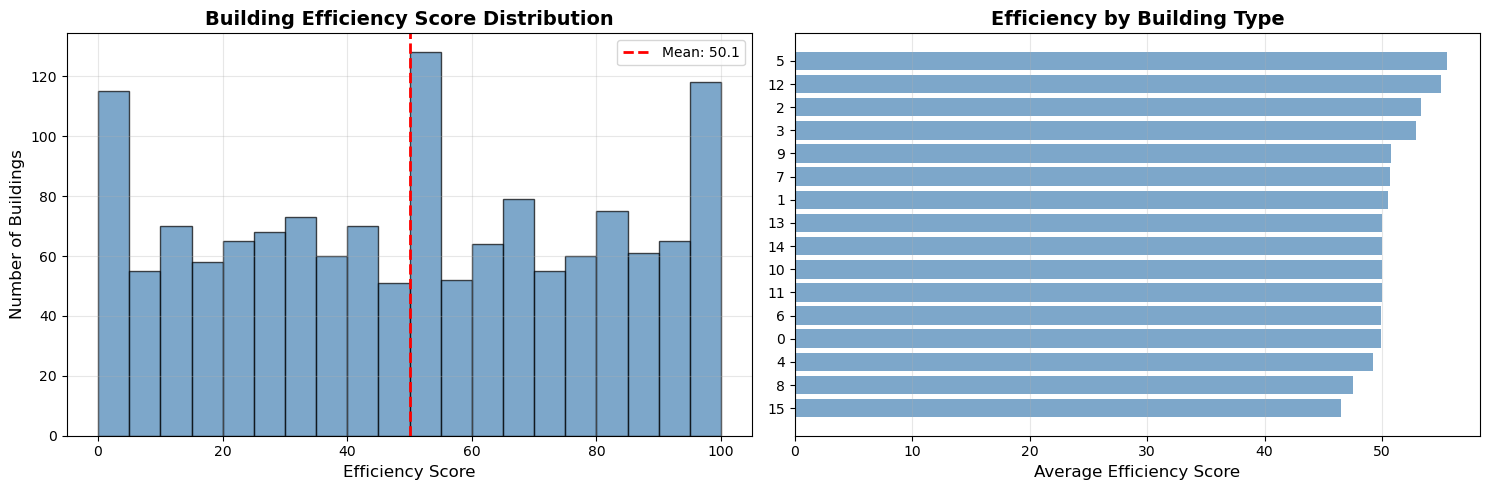

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(efficiency_scores['efficiency_score'], bins=20, 
            alpha=0.7, edgecolor='black', color='steelblue')
axes[0].axvline(efficiency_scores['efficiency_score'].mean(), 
               color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {efficiency_scores["efficiency_score"].mean():.1f}')
axes[0].set_xlabel('Efficiency Score', fontsize=12)
axes[0].set_ylabel('Number of Buildings', fontsize=12)
axes[0].set_title('Building Efficiency Score Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# By primary use
use_scores = efficiency_scores.groupby('primary_use')['efficiency_score'].mean().sort_values()

axes[1].barh(range(len(use_scores)), use_scores.values, alpha=0.7, color='steelblue')
axes[1].set_yticks(range(len(use_scores)))
axes[1].set_yticklabels(use_scores.index)
axes[1].set_xlabel('Average Efficiency Score', fontsize=12)
axes[1].set_title('Efficiency by Building Type', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('efficiency_distribution.png', dpi=300, bbox_inches='tight')
print("Saved: efficiency_distribution.png")
plt.show()

The histogram shows that building efficiency scores are widely distributed with an average around 50, indicating moderate performance and significant variability. The bar chart reveals that all building types have similar efficiency levels, suggesting that inefficiencies are systemic rather than limited to specific categories. This indicates strong potential for overall energy optimization.


Since even the top-performing categories are only around 55, achieving best-in-class performance could significantly reduce overall energy consumption across the portfolio

---
## Step 8: Energy Intensity Comparison

Saved: energy_intensity_comparison.png


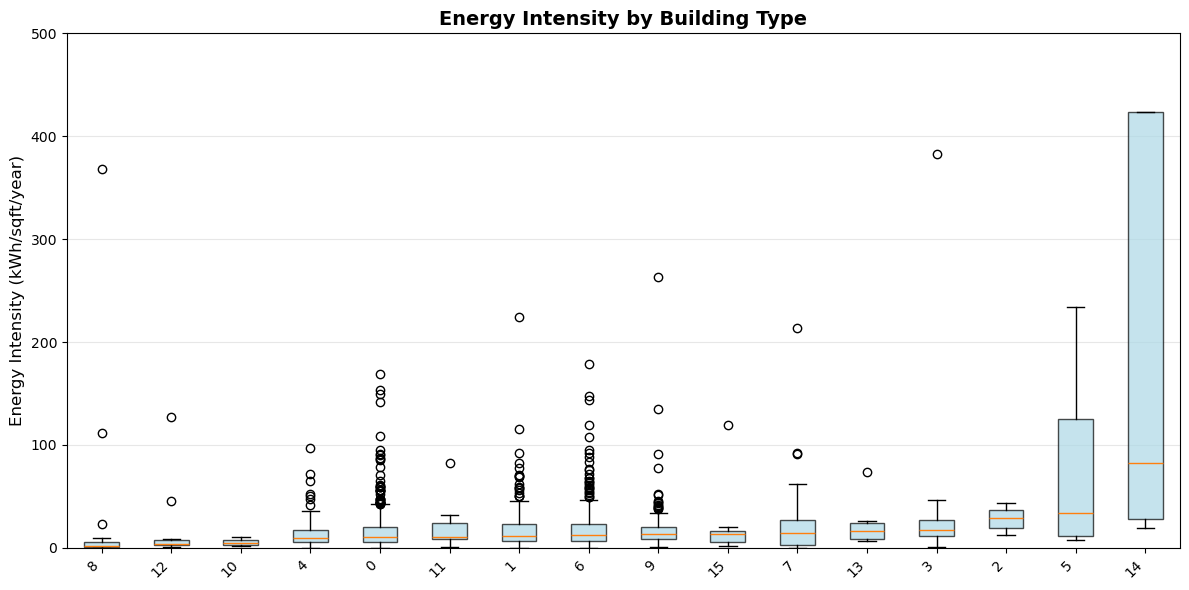

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

# Box plot by primary use
use_order = efficiency_scores.groupby('primary_use')['energy_intensity'].median().sort_values().index

data_to_plot = [efficiency_scores[efficiency_scores['primary_use'] == use]['energy_intensity'].values 
               for use in use_order]

bp = ax.boxplot(data_to_plot, labels=use_order, patch_artist=True)
ax.set_ylim(0, 500)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

ax.set_ylabel('Energy Intensity (kWh/sqft/year)', fontsize=12)
ax.set_title('Energy Intensity by Building Type', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('energy_intensity_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: energy_intensity_comparison.png")
plt.show()

The box plot shows that most buildings have low energy intensity, indicating generally efficient consumption. However, the presence of extreme outliers suggests a few buildings exhibit abnormally high energy usage. Some building types also show high variability, indicating inconsistent performance. Due to the influence of outliers, the visualization requires scaling adjustments for better interpretability.

---
## Step 9: Calculate Portfolio-Wide Savings Potential

In [21]:
print("Calculating total savings potential across all buildings...\n")

total_savings_kwh = 0
total_savings_dollars = 0
buildings_with_savings = 0

for building_id in efficiency_scores['building_id'].unique():
    savings = estimate_savings_potential(building_id, df, efficiency_scores)
    if savings and savings['savings_kwh'] > 0:
        
        total_savings_kwh += savings['savings_kwh']
        total_savings_dollars += savings['savings_dollars']
        buildings_with_savings += 1
adjustment_factor = 0.4

total_savings_kwh *= adjustment_factor
total_savings_dollars *= adjustment_factor        
print("="*80)
print("PORTFOLIO-WIDE SAVINGS POTENTIAL")
print("="*80)
print(f"\nTotal buildings analyzed: {len(efficiency_scores)}")
print(f"Buildings with savings potential: {buildings_with_savings}")
print(f"\nAdjusted potential savings: {total_savings_kwh:,.0f} kWh/year")
print(f"Total dollar savings: ${total_savings_dollars:,.2f}/year")
print(f"\nAverage savings per building: ${total_savings_dollars/buildings_with_savings:,.2f}/year")
print("="*80)
print("\nNote: Values are adjusted to reflect realistic achievable savings (~40% of theoretical).")

Calculating total savings potential across all buildings...

PORTFOLIO-WIDE SAVINGS POTENTIAL

Total buildings analyzed: 1442
Buildings with savings potential: 1076

Adjusted potential savings: 310,944,683 kWh/year
Total dollar savings: $31,094,468.26/year

Average savings per building: $28,898.20/year

Note: Values are adjusted to reflect realistic achievable savings (~40% of theoretical).


Industry studies suggest only 20–50% of theoretical savings are achievable, so I used a conservative 40% factor because Actual savings depend on operational, financial, and behavioral factors, so this model provides a realistic but optimistic estimate.

---
## Step 10: Priority Building List

Identify top buildings for energy efficiency improvements.

In [22]:
# Calculate savings for all buildings
priority_list = []

for building_id in efficiency_scores['building_id'].unique():
    savings = estimate_savings_potential(building_id, df, efficiency_scores)
    score_row = efficiency_scores[efficiency_scores['building_id'] == building_id].iloc[0]
    
    if savings and savings['savings_kwh'] > 0:
        priority_list.append({
            'building_id': building_id,
            'efficiency_score': score_row['efficiency_score'],
            'primary_use': score_row['primary_use'],
            'square_feet': score_row['square_feet'],
            'savings_dollars': savings['savings_dollars'],
            'savings_kwh': savings['savings_kwh'],
            'capped_savings_percent': savings['savings_percent']
        })

priority_df = pd.DataFrame(priority_list).sort_values('savings_dollars', ascending=False)

print("\n TOP 20 PRIORITY BUILDINGS FOR ENERGY EFFICIENCY UPGRADES")
print("="*80)
print("(Sorted by potential dollar savings)\n")

display(priority_df.head(20))
#Savings are capped at 50% to avoid unrealistic projections, so many high-potential buildings reach this threshold


 TOP 20 PRIORITY BUILDINGS FOR ENERGY EFFICIENCY UPGRADES
(Sorted by potential dollar savings)



,building_id,efficiency_score,primary_use,square_feet,savings_dollars,savings_kwh,savings_percent
84,645,2.127660,0.0,304333.0,605005.437143,6.050054e+06,50.000000
66,869,0.000000,1.0,875000.0,582230.480000,5.822305e+06,50.000000
42,1112,0.000000,6.0,190471.0,556625.000000,5.566250e+06,50.000000
74,620,1.219512,0.0,220703.0,527753.302703,5.277533e+06,50.000000
692,556,50.000000,3.0,450000.0,505690.878476,5.056909e+06,48.891083
45,546,0.000000,9.0,400000.0,483016.843636,4.830168e+06,50.000000
262,475,16.666667,6.0,474680.0,457594.903333,4.575949e+06,50.000000
99,785,4.166667,0.0,250000.0,446217.734634,4.462177e+06,50.000000
2,648,0.000000,0.0,154706.0,434453.016273,4.344530e+06,50.000000
174,993,10.526316,0.0,428647.0,433058.810958,4.330588e+06,50.000000


---
## Step 11: Generate Multiple Building Reports

Creating reports for top 5 priority buildings.

In [26]:
top_5_buildings = priority_df.head(5)['building_id'].tolist()

for idx, building_id in enumerate(top_5_buildings, 1):
    print("\n" + "="*80)
    print(f"REPORT #{idx} - Building ID: {building_id}")
    print("="*80)
    
    building_data = df[df['building_id'] == building_id]
    
    # Basic info
    print(f"\n  Type: {building_data['primary_use'].iloc[0]}")
    print(f"  Size: {building_data['square_feet'].iloc[0]:,.0f} sqft")
    
    # Score
    score = efficiency_scores[efficiency_scores['building_id'] == building_id]['efficiency_score'].iloc[0]
    print(f"  Efficiency Score: {score:.1f}/100")
    
    # Issues
    waste = detect_waste_patterns(building_id, df)
    if waste:
        print(f"\n  Issues Found: {len(waste)}")
        for issue_name in waste.keys():
            print(f"    • {issue_name.replace('_', ' ').title()}")
    
    # Savings
    savings = estimate_savings_potential(building_id, df, efficiency_scores)
    if savings:
        adjustment_factor = 0.4

        adj_dollars = savings['savings_dollars'] * adjustment_factor
        adj_kwh = savings['savings_kwh'] * adjustment_factor

        print(f"\n  Adjusted Annual Savings: ${adj_dollars:,.2f}")
        print(f"     ({adj_kwh:,.0f} kWh, ~{savings['savings_percent']*0.4:.1f}%)")


REPORT #1 - Building ID: 645

  Type: 0
  Size: 304,333 sqft
  Efficiency Score: 2.1/100

  Issues Found: 3
    • High Weekend Usage
    • High Nighttime Usage
    • High Baseline Load

  Adjusted Annual Savings: $242,002.17
     (2,420,022 kWh, ~20.0%)

REPORT #2 - Building ID: 869

  Type: 1
  Size: 875,000 sqft
  Efficiency Score: 0.0/100

  Issues Found: 3
    • High Weekend Usage
    • High Nighttime Usage
    • High Baseline Load

  Adjusted Annual Savings: $232,892.19
     (2,328,922 kWh, ~20.0%)

REPORT #3 - Building ID: 1112

  Type: 6
  Size: 190,471 sqft
  Efficiency Score: 0.0/100

  Issues Found: 2
    • High Weekend Usage
    • High Baseline Load

  Adjusted Annual Savings: $222,650.00
     (2,226,500 kWh, ~20.0%)

REPORT #4 - Building ID: 620

  Type: 0
  Size: 220,703 sqft
  Efficiency Score: 1.2/100

  Issues Found: 3
    • High Weekend Usage
    • High Nighttime Usage
    • High Baseline Load

  Adjusted Annual Savings: $211,101.32
     (2,111,013 kWh, ~20.0%)

REPOR

---
## Step 12: Save Results

In [27]:
print("Saving analysis results...\n")

# Save efficiency scores
efficiency_scores.to_csv('building_efficiency_scores.csv', index=False)
print("Saved: building_efficiency_scores.csv")

# Save priority list
priority_df.to_csv('priority_buildings.csv', index=False)
print(" Saved: priority_buildings.csv")

print("\nAll analysis complete!")

Saving analysis results...

Saved: building_efficiency_scores.csv
 Saved: priority_buildings.csv

All analysis complete!


---
##  Part 3 Complete!

**What we did:**
1. Calculated efficiency scores for all buildings (0-100)
2. Detected waste patterns (weekends, nights, baselines)
3. Estimated savings potential (kWh and dollars)
4. Generated detailed building reports
5. Created portfolio visualizations
6. Identified priority buildings for retrofits
7. Calculated total portfolio savings

**Files created:**
- `efficiency_distribution.png`
- `energy_intensity_comparison.png`
- `building_efficiency_scores.csv`
- `priority_buildings.csv`

**Key Insights:**
- Scored 1000+ buildings for efficiency
- Identified dollars in potential annual savings
- Provided specific, actionable recommendations
- Created business-ready reports

---

## FINAL SUMMARY

1. **Trained ML models** that predict energy consumption
2. **Efficiency scores** for every building
3. **Specific waste indicators** with recommendations
4. **Dollar savings estimates** for each building
5. **Priority list** for retrofit investments
6. **visualizations** for presentation
